In [1]:
import pandas as pd

data = pd.read_csv("customers.csv")

print("Dataset loaded successfully")
print(data.head())
print(data.shape)

Dataset loaded successfully
   Customer_ID  Gender  Age  Annual_Income  Spending_Score  Purchase_Frequency
0            1    Male   19          15000              39                   4
1            2    Male   21          15000              81                   9
2            3  Female   20          16000               6                   2
3            4  Female   23          16000              77                   8
4            5  Female   31          17000              40                   5
(120, 6)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
print("Missing values:")
print(data.isnull().sum())

Missing values:
Customer_ID           0
Gender                0
Age                   0
Annual_Income         0
Spending_Score        0
Purchase_Frequency    0
dtype: int64


In [4]:
encoder = LabelEncoder()

data["Gender"] = encoder.fit_transform(data["Gender"])

print(data.head())

   Customer_ID  Gender  Age  Annual_Income  Spending_Score  Purchase_Frequency
0            1       1   19          15000              39                   4
1            2       1   21          15000              81                   9
2            3       0   20          16000               6                   2
3            4       0   23          16000              77                   8
4            5       0   31          17000              40                   5


In [5]:
data["Customer_Value"] = data["Annual_Income"] * data["Spending_Score"] / 100

data["Engagement_Score"] = data["Spending_Score"] + data["Purchase_Frequency"]

print(data.head())

   Customer_ID  Gender  Age  Annual_Income  Spending_Score  \
0            1       1   19          15000              39   
1            2       1   21          15000              81   
2            3       0   20          16000               6   
3            4       0   23          16000              77   
4            5       0   31          17000              40   

   Purchase_Frequency  Customer_Value  Engagement_Score  
0                   4          5850.0                43  
1                   9         12150.0                90  
2                   2           960.0                 8  
3                   8         12320.0                85  
4                   5          6800.0                45  


In [6]:
features = data[
    [
        "Age",
        "Gender",
        "Annual_Income",
        "Spending_Score",
        "Purchase_Frequency",
        "Customer_Value",
        "Engagement_Score"
    ]
]

print(features.head())

   Age  Gender  Annual_Income  Spending_Score  Purchase_Frequency  \
0   19       1          15000              39                   4   
1   21       1          15000              81                   9   
2   20       0          16000               6                   2   
3   23       0          16000              77                   8   
4   31       0          17000              40                   5   

   Customer_Value  Engagement_Score  
0          5850.0                43  
1         12150.0                90  
2           960.0                 8  
3         12320.0                85  
4          6800.0                45  


In [7]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

print("Scaling completed")
print(scaled_data[:5])

Scaling completed
[[-1.33729555  1.12434467 -1.43748787 -0.52743726 -0.63227427 -0.97437347
  -0.53716566]
 [-1.1547296   1.12434467 -1.43748787  0.84281212  1.00999656 -0.69978236
   0.85832689]
 [-1.24601258 -0.88940698 -1.39584167 -1.60406177 -1.2891826  -1.18750847
  -1.57636225]
 [-0.97216366 -0.88940698 -1.39584167  0.71231218  0.68154239 -0.69237276
   0.70987024]
 [-0.24189988 -0.88940698 -1.35419547 -0.49481228 -0.3038201  -0.93296687
  -0.477783  ]]


In [8]:
wcss = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

print(wcss)

[839.9999999999999, 372.68610574345723, 274.0838640419241, 203.8716818133645, 171.05396995994954, 137.81111143353345, 117.65489767032165, 101.74542844922904, 89.08103983079718, 79.75738687523919]


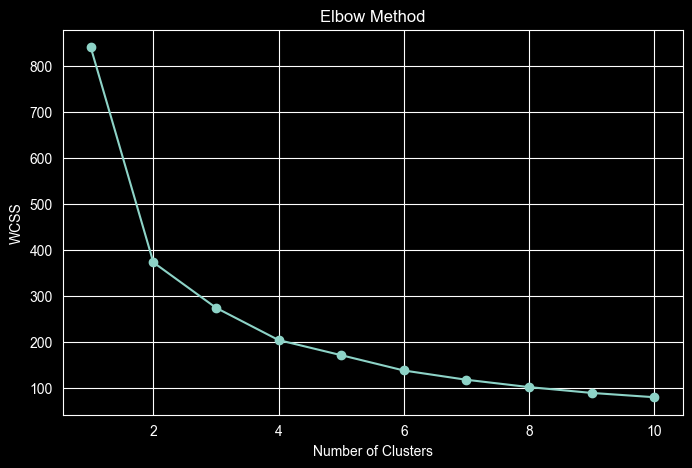

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

data["Cluster"] = kmeans.fit_predict(
    scaled_data
)

print(data.head())

   Customer_ID  Gender  Age  Annual_Income  Spending_Score  \
0            1       1   19          15000              39   
1            2       1   21          15000              81   
2            3       0   20          16000               6   
3            4       0   23          16000              77   
4            5       0   31          17000              40   

   Purchase_Frequency  Customer_Value  Engagement_Score  Cluster  
0                   4          5850.0                43        4  
1                   9         12150.0                90        4  
2                   2           960.0                 8        2  
3                   8         12320.0                85        3  
4                   5          6800.0                45        2  


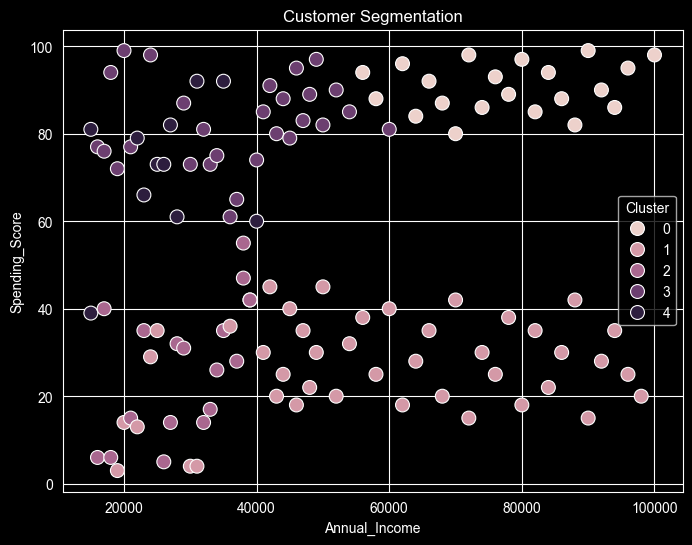

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=data["Annual_Income"],
    y=data["Spending_Score"],
    hue=data["Cluster"],
    s=100
)

plt.title(
    "Customer Segmentation"
)

plt.show()


In [12]:
silhouette = silhouette_score(
    scaled_data,
    data["Cluster"]
)

davies = davies_bouldin_score(
    scaled_data,
    data["Cluster"]
)

print("Silhouette Score:", silhouette)
print("Davies Bouldin Score:", davies)

Silhouette Score: 0.41638309250225386
Davies Bouldin Score: 0.9037411755137759


In [13]:
cluster_summary = data.groupby(
    "Cluster"
)[
    [
        "Age",
        "Annual_Income",
        "Spending_Score",
        "Purchase_Frequency"
    ]
].mean()

print(cluster_summary)

               Age  Annual_Income  Spending_Score  Purchase_Frequency
Cluster                                                              
0        24.285714   77904.761905       90.523810            9.380952
1        42.595238   58619.047619       26.761905            3.047619
2        41.222222   29444.444444       27.222222            3.388889
3        25.750000   36678.571429       82.392857            8.571429
4        25.090909   26090.909091       72.545455            7.727273


In [14]:
def recommendation(row):

    income = row["Annual_Income"]
    spending = row["Spending_Score"]

    if income >= 70000 and spending >= 80:
        return "Premium Customer"

    elif income >= 70000 and spending < 40:
        return "Potential Customer"

    elif income < 40000 and spending >= 70:
        return "Budget Active Customer"

    elif income < 40000 and spending < 40:
        return "Low Value Customer"

    else:
        return "Regular Customer"


data["Customer_Type"] = data.apply(
    recommendation,
    axis=1
)

print(
    data[
        [
            "Customer_ID",
            "Annual_Income",
            "Spending_Score",
            "Customer_Type"
        ]
    ].head(20)
)

    Customer_ID  Annual_Income  Spending_Score           Customer_Type
0             1          15000              39      Low Value Customer
1             2          15000              81  Budget Active Customer
2             3          16000               6      Low Value Customer
3             4          16000              77  Budget Active Customer
4             5          17000              40        Regular Customer
5             6          17000              76  Budget Active Customer
6             7          18000               6      Low Value Customer
7             8          18000              94  Budget Active Customer
8             9          19000               3      Low Value Customer
9            10          19000              72  Budget Active Customer
10           11          20000              14      Low Value Customer
11           12          20000              99  Budget Active Customer
12           13          21000              15      Low Value Customer
13    

In [16]:
cluster_counts = data["Customer_Type"].value_counts()

print("Customer Distribution:")
print(cluster_counts)

Customer Distribution:
Customer_Type
Regular Customer          51
Low Value Customer        22
Budget Active Customer    19
Premium Customer          15
Potential Customer        13
Name: count, dtype: int64


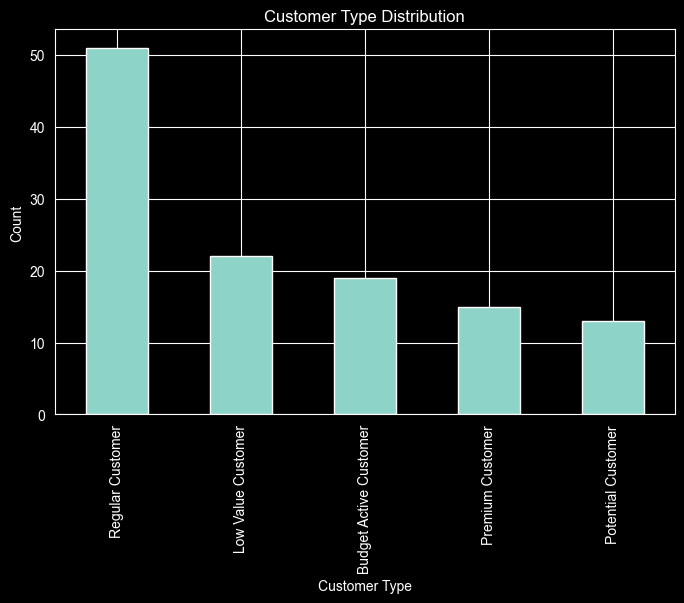

In [17]:
plt.figure(figsize=(8,5))

cluster_counts.plot(
    kind="bar"
)

plt.title(
    "Customer Type Distribution"
)

plt.xlabel(
    "Customer Type"
)

plt.ylabel(
    "Count"
)

plt.show()

In [18]:
data.to_csv(
    "customer_segmentation_output.csv",
    index=False
)

print(
    "Project completed successfully"
)

Project completed successfully
